In [23]:
import torch.nn as nn, torch
import math, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandas as pd, pickle, copy, os

In [24]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def sinusoidal_encodings(n_tokens=540, dim=128):
    position = torch.arange(n_tokens, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, dim, 2, dtype=torch.float32) * (-math.log(10000.0) / dim)
    )
    mat = torch.zeros(n_tokens, dim)
    mat[:, 0::2] = torch.sin(position * div_term)
    mat[:, 1::2] = torch.cos(position * div_term)
    return mat  # no manual device/for-loop needed; register_buffer handles device

class MultiHeadAttention(nn.Module):
    """No residual inside anymore — residual now handled by the pre-LN block."""
    def __init__(self, dropout=0.2):
        super().__init__()
        self.q = nn.Linear(128, 128)
        self.k = nn.Linear(128, 128)
        self.v = nn.Linear(128, 128)
        self.o = nn.Linear(128, 128)
        self.attn_drop = nn.Dropout(dropout)  # matches internal MHA attn-weight dropout

    def forward(self, x):  # x -> (B, L, 128), already LayerNorm'd by caller
        B, a, b = x.shape
        query = self.q(x)
        key   = self.k(x)
        value = self.v(x)

        query = torch.stack(query.chunk(4, dim=-1), dim=1)  # (B,4,L,32)
        key   = torch.stack(key.chunk(4, dim=-1), dim=1)
        value = torch.stack(value.chunk(4, dim=-1), dim=1)

        attention = (query @ key.permute(0, 1, 3, 2)) / math.sqrt(32)
        attention = F.softmax(attention, dim=-1)
        attention = self.attn_drop(attention)

        context = attention @ value
        context = context.transpose(1, 2).reshape(B, a, b)
        context = self.o(context)
        return context  # NOTE: no "+ x" here anymore

class EncoderBlock(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.attn = MultiHeadAttention(dropout)
        self.norm1 = nn.LayerNorm(128)
        self.drop1 = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
        )
        self.norm2 = nn.LayerNorm(128)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        # Pre-LN, matches nn.TransformerEncoderLayer(norm_first=True)
        x = x + self.drop1(self.attn(self.norm1(x)))
        x = x + self.drop2(self.ffn(self.norm2(x)))
        return x

class EmbeddingModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(14, 128)
        self.conv = nn.Conv1d(128, 128, kernel_size=5, stride=4, padding=2)
        self.act1 = nn.GELU()
        self.conv2 = nn.Conv1d(128, 128, kernel_size=5, stride=2, padding=2)
        self.act2 = nn.GELU()
        self.register_buffer("pos_enc", sinusoidal_encodings(540, 128))

    def forward(self, x):
        x = self.input_proj(x)
        x = x.transpose(1, 2)
        x = self.act1(self.conv(x))
        x = self.act2(self.conv2(x))
        x = x.transpose(1, 2)
        x = x + self.pos_enc.unsqueeze(0)
        return x

class Transformer(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.embed = EmbeddingModel()
        self.e1 = EncoderBlock(dropout)
        self.e2 = EncoderBlock(dropout)
        self.e3 = EncoderBlock(dropout)
        self.fl = nn.Flatten()
        self.decoder = nn.Sequential(
            nn.LayerNorm(128*3),
            nn.Linear(128*3, 144),  
        )

    def forward(self, x):
        x = self.embed(x)
        x = self.e1(x)
        x = self.e2(x)
        x = self.e3(x)
        x = x[:, -3:, :]
        x = self.fl(x)
        x = self.decoder(x)
        return x

In [25]:
class ClimateLog(Dataset):
    def __init__(self, root, split="train"):
        super().__init__()
        self.root = root
        self.scaler = StandardScaler()

        df = pd.read_csv(self.root).copy()
        del df['Date Time']

        df = df.iloc[:-4320].copy()

        n = len(df)
        train_end = int(0.8 * n)
        val_end   = int(0.9 * n)

        train_df = df.iloc[:train_end].copy()
        val_df   = df.iloc[train_end:val_end].copy()
        test_df  = df.iloc[val_end:].copy()

        self.train_dataset = torch.tensor(
            self.scaler.fit_transform(train_df.values),
            dtype=torch.float32
        )
        self.val_dataset = torch.tensor(
            self.scaler.transform(val_df.values),
            dtype=torch.float32
        )
        self.test_dataset = torch.tensor(
            self.scaler.transform(test_df.values),
            dtype=torch.float32
        )

        self.stride = 24
        self.split = split 

    def __len__(self):
        dataset = self._get_dataset()
        return (len(dataset) - 4320 - 144 + 1) // self.stride

    def __getitem__(self, index):
        index *= self.stride
        dataset = self._get_dataset()

        inputs = dataset[index:index+4320, :]
        labels = dataset[index+4320:index+4320+144, 2]

        return inputs, labels

    def _get_dataset(self):
        if self.split == "train":
            return self.train_dataset
        elif self.split == "val":
            return self.val_dataset
        elif self.split == "test":
            return self.test_dataset
        else:
            raise ValueError(f"Unknown split: {self.split}")


In [26]:
BATCH_SIZE = 128
DEVICE = torch.device('cuda')

In [27]:
train_dataset = ClimateLog("/kaggle/input/datasets/quphine/jena-climate/jena_climate_2009_2016.csv", split='train')
val_dataset = ClimateLog("/kaggle/input/datasets/quphine/jena-climate/jena_climate_2009_2016.csv", split='val')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [ ]:
def train_model(
    model, optimizer, criterion, train_loader, val_loader,
    scheduler, loss_dict, acc_dict, n_epochs, device,
    checkpoint_path="model_checkpoint.pth"
):
    start_epoch = 0
    best_loss    = 1000.0

    if torch.cuda.device_count() > 1 and not isinstance(model, nn.DataParallel):
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
    model = model.to(device)

    if os.path.exists(checkpoint_path):
        print("Checkpoint found. Resuming training...")
        ckpt = torch.load(checkpoint_path, map_location=device)
        (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        best_loss    = ckpt["best_loss"]
        loss_dict.update(ckpt["loss_dict"])
        acc_dict.update(ckpt["acc_dict"])
        print(f"Resumed from Epoch {start_epoch}")

    best_wts = copy.deepcopy(
        (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
    )

    for epoch in range(start_epoch, n_epochs):
        print(f"\nEpoch [{epoch+1}/{n_epochs}]  lr={scheduler.get_last_lr()[0]:.6f}")

        model.train()
        train_loss = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item() * inputs.size(0)

            if (i + 1) % 50 == 0 or (i + 1) == len(train_loader):
                print(f"  Step [{i+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

        epoch_train_loss = train_loss    / len(train_loader.dataset)
        loss_dict["train"].append(epoch_train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs    = model(inputs)
                loss       = criterion(outputs, labels)
                val_loss  += loss.item() * inputs.size(0)

        epoch_val_loss = val_loss    / len(val_loader.dataset)
        loss_dict["val"].append(epoch_val_loss)

        scheduler.step()

        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            best_wts = copy.deepcopy(
                (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
            )

        print("-" * 60)
        print(f"Train Loss: {epoch_train_loss:.4f} ")
        print(f"Val   Loss: {epoch_val_loss:.4f} (best: {best_loss:.4f})")
        print("-" * 60)

        raw_state = (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     raw_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_loss":             best_loss,
            "loss_dict":            loss_dict,
            "acc_dict":             acc_dict,
        }, checkpoint_path)

    torch.save(best_wts, "model_wts.pth")
    with open("acc_loss.bin", "wb") as f:
        pickle.dump([loss_dict, acc_dict], f)

    (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(best_wts)
    print(f"\nTraining Complete! Best Val loss: {best_loss:.4f}")
    return model

In [ ]:
device = 'cuda'
num_epochs = 50

criterion = nn.MSELoss()
model = Transformer()
model.to(device)



optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-1)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,   
    eta_min=1e-6,       
)
KAGGLE_INPUT_CHECKPOINT = "model_checkpoint.pth"
OUTPUT_CHECKPOINT_PATH  = "/working/latest_checkpoint.pth"

import shutil
if os.path.exists(KAGGLE_INPUT_CHECKPOINT) and not os.path.exists(OUTPUT_CHECKPOINT_PATH):
    print("Linking Kaggle input checkpoint...")
    shutil.copy(KAGGLE_INPUT_CHECKPOINT, OUTPUT_CHECKPOINT_PATH)

loss_dict = {'train': [], 'val': []}
acc_dict  = {'train': [], 'val': []}

train_model(
    model=model,
    device=device,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=scheduler,
    loss_dict=loss_dict,
    acc_dict=acc_dict,
    n_epochs=num_epochs,
    checkpoint_path=OUTPUT_CHECKPOINT_PATH,
)

hi
Using 2 GPUs
Checkpoint found. Resuming training...
Resumed from Epoch 50

Training Complete! Best Val loss: 0.1020


DataParallel(
  (module): Transformer(
    (embed): EmbeddingModel(
      (input_proj): Linear(in_features=14, out_features=128, bias=True)
      (conv): Conv1d(128, 128, kernel_size=(5,), stride=(4,), padding=(2,))
      (act1): GELU(approximate='none')
      (conv2): Conv1d(128, 128, kernel_size=(5,), stride=(2,), padding=(2,))
      (act2): GELU(approximate='none')
    )
    (e1): EncoderBlock(
      (attn): MultiHeadAttention(
        (q): Linear(in_features=128, out_features=128, bias=True)
        (k): Linear(in_features=128, out_features=128, bias=True)
        (v): Linear(in_features=128, out_features=128, bias=True)
        (o): Linear(in_features=128, out_features=128, bias=True)
        (attn_drop): Dropout(p=0.2, inplace=False)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drop1): Dropout(p=0.2, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')

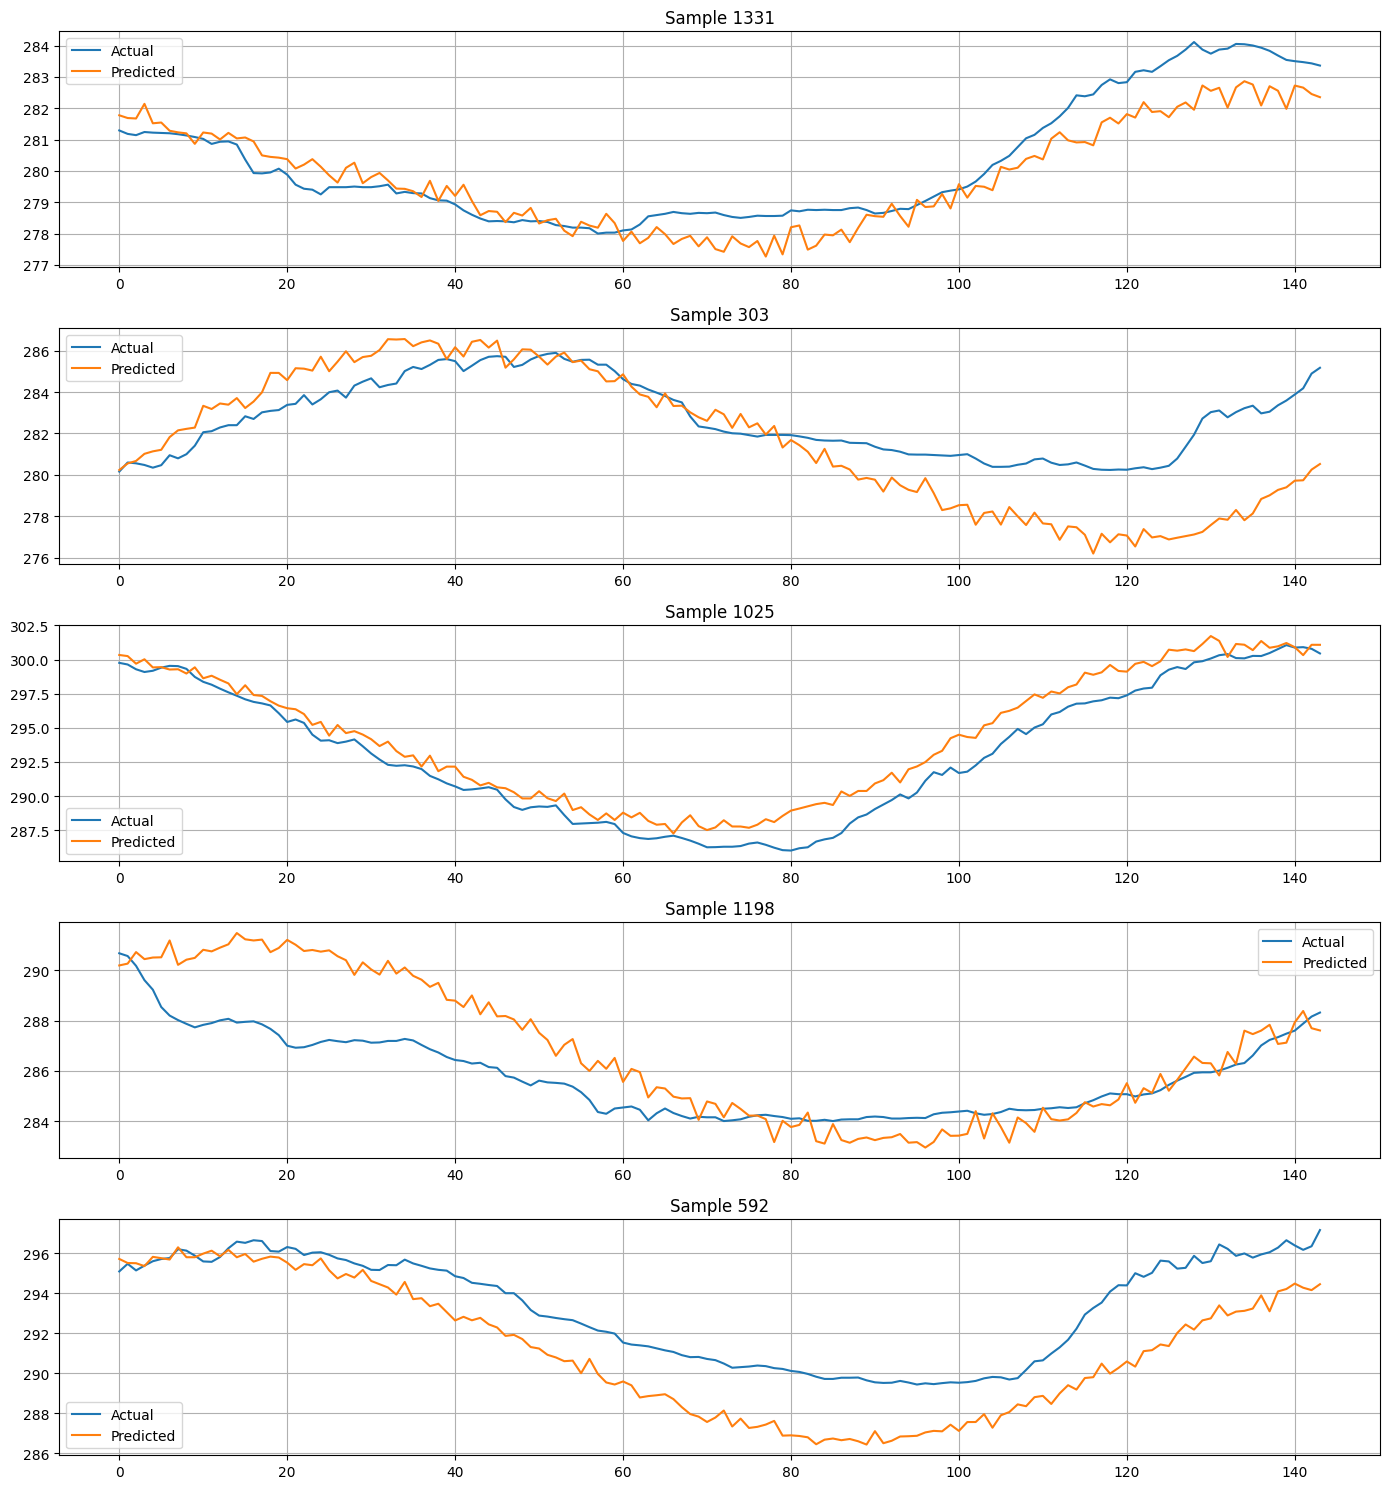

In [48]:
import random
import matplotlib.pyplot as plt

temp_mean = test_dataset.scaler.mean_[2]
temp_std  = test_dataset.scaler.scale_[2]

model.eval()

fig, axes = plt.subplots(5, 1, figsize=(14, 15))

for ax in axes:

    idx = random.randint(0, len(test_dataset)-1)

    x, y = test_dataset[idx]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).squeeze().cpu()

    pred = pred.numpy() * temp_std + temp_mean
    actual = y.numpy() * temp_std + temp_mean

    ax.plot(actual, label="Actual")
    ax.plot(pred, label="Predicted")

    ax.set_title(f"Sample {idx}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#evaluation

model.eval()

preds = []
targets = []

with torch.no_grad():
    for x, y in test_loader:
        pred = model(x.to(device))
        preds.append(pred.cpu())
        targets.append(y)

preds = torch.cat(preds)
targets = torch.cat(targets)

pred_np = preds.numpy()
target_np = targets.numpy()

temp_mean = test_dataset.scaler.mean_[2]
temp_std = test_dataset.scaler.scale_[2]

pred_c = pred_np * temp_std + temp_mean
target_c = target_np * temp_std + temp_mean


mae = mean_absolute_error(target_c.flatten(), pred_c.flatten())
rmse = np.sqrt(mean_squared_error(target_c.flatten(), pred_c.flatten()))
r2 = r2_score(target_c.flatten(), pred_c.flatten())

print("="*80)
print("OVERALL METRICS")
print("="*80)
print(f"MAE             : {mae:.3f} °C")
print(f"RMSE            : {rmse:.3f} °C")
print(f"R²              : {r2:.4f}")
print(f"Correlation     : {np.corrcoef(pred_c.flatten(),target_c.flatten())[0,1]:.4f}")
print()


sample_mae = np.mean(np.abs(pred_c-target_c),axis=1)

print("="*80)
print("SAMPLE ERROR DISTRIBUTION")
print("="*80)
print(f"Best MAE        : {sample_mae.min():.3f} °C")
print(f"Median MAE      : {np.median(sample_mae):.3f} °C")
print(f"Mean MAE        : {sample_mae.mean():.3f} °C")
print(f"Worst MAE       : {sample_mae.max():.3f} °C")
print()

for t in [1,2,3,4,5,6]:
    print(f"Samples > {t}°C : {np.sum(sample_mae>t)}")

print()






OVERALL METRICS
MAE             : 1.825 °C
RMSE            : 2.417 °C
R²              : 0.8914
Correlation     : 0.9446

SAMPLE ERROR DISTRIBUTION
Best MAE        : 0.382 °C
Median MAE      : 1.597 °C
Mean MAE        : 1.825 °C
Worst MAE       : 7.228 °C

Samples > 1°C : 1305
Samples > 2°C : 514
Samples > 3°C : 175
Samples > 4°C : 49
Samples > 5°C : 13
Samples > 6°C : 4

